# **SeqDiff: Zero-Shot MRI Sequence Translation via Sequence-Conditioned Diffusion with Cross-Attention Fusion for AIoT-Enabled Healthcare Networks** 🧠🌐

> **Conference Target:** ITC Egypt 2026 — Track 4: AI and Machine Learning for Communications, Subtopic 10: Artificial Intelligence and Machine Learning for IoT

> **Core Contribution:** A sequence-conditioned diffusion model for zero-shot MRI synthesis deployed as an edge-inference service in AIoT healthcare networks, reducing cross-sequence transmission bandwidth while enabling complete diagnostic imaging in resource-constrained environments.

## Importing Libraries & Loading Data

In [1]:
!pip install -q monai nibabel diffusers accelerate lpips \
             scikit-image wandb torchio torch-ema

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.2/196.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.4 MB/s eta 0:00:00


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os, glob, random, warnings
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import lpips
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import wandb

warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00495.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar
/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00621.tar


In [3]:
# ============================================================
# CELL: Extract .tar files in Kaggle (fast, in-memory)
# ============================================================
import tarfile, os
from pathlib import Path

INPUT_PATH  = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"   # adjust to your dataset path
OUTPUT_PATH = "/kaggle/working/brats_extracted"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Find all tar files
tar_files = list(Path(INPUT_PATH).glob("*.tar"))
print(f"Found tar files: {tar_files}")

for tar_path in tar_files:
    print(f"Extracting {tar_path.name}...")
    with tarfile.open(tar_path, "r") as tar:
        tar.extractall(OUTPUT_PATH)
    print(f"✅ Done")

# Check what we got
extracted = os.listdir(OUTPUT_PATH)
print(f"\nExtracted {len(extracted)} items")
print("Sample:", extracted[:3])

Found tar files: [PosixPath('/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00495.tar'), PosixPath('/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar'), PosixPath('/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_00621.tar')]
Extracting BraTS2021_00495.tar...
✅ Done
Extracting BraTS2021_Training_Data.tar...
✅ Done
Extracting BraTS2021_00621.tar...
✅ Done

Extracted 1262 items
Sample: ['BraTS2021_01468', 'BraTS2021_00645', 'BraTS2021_00033']


### Load & Preprocess ON-THE-FLY (no saving to disk)

In [4]:
import os, glob, random
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize

DATA_PATH = "/kaggle/working/brats_extracted"
SUBJECTS  = sorted(os.listdir(DATA_PATH))

class BraTSStreamDataset(Dataset):
    """Loads slices on-the-fly — zero preprocessing wait"""
    
    def __init__(self, subjects, input_seqs, target_seq, img_size=256):
        self.subjects    = subjects
        self.input_seqs  = input_seqs   # e.g. ["t1", "t2"]
        self.target_seq  = target_seq   # e.g. "flair"
        self.img_size    = img_size
        self.slice_index = self._build_index()

    def _build_index(self):
        """Pre-index valid slices without loading volumes"""
        index = []
        for subj in self.subjects:
            subj_path = os.path.join(DATA_PATH, subj)
            # BraTS has 155 axial slices, brain present in ~60-130
            for sl in range(60, 130):
                index.append((subj_path, subj, sl))
        return index

    def _load_slice(self, subj_path, subj_name, seq, sl_idx):
        pattern = os.path.join(subj_path, f"{subj_name}_{seq}.nii.gz")
        vol = nib.load(pattern).get_fdata()
        sl  = vol[:, :, sl_idx].astype(np.float32)
        sl  = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
        sl  = resize(sl, (self.img_size, self.img_size), anti_aliasing=True)
        return sl.astype(np.float32)

    def __len__(self):
        return len(self.slice_index)

    def __getitem__(self, idx):
        subj_path, subj_name, sl_idx = self.slice_index[idx]
        
        # Load input sequences → stack as channels
        inputs = np.stack([
            self._load_slice(subj_path, subj_name, s, sl_idx)
            for s in self.input_seqs
        ], axis=0)
        
        # Load target sequence
        target = self._load_slice(
            subj_path, subj_name, self.target_seq, sl_idx
        )[np.newaxis]
        
        return torch.FloatTensor(inputs), torch.FloatTensor(target)

### Create Dataloaders instantly

In [5]:
n       = len(SUBJECTS)
train_s = SUBJECTS[:int(n*0.75)]
val_s   = SUBJECTS[int(n*0.75):int(n*0.85)]
test_s  = SUBJECTS[int(n*0.85):]


train_ds = BraTSStreamDataset(train_s, ["t1", "t2"], "flair")
val_ds   = BraTSStreamDataset(val_s,   ["t1", "t2"], "flair")
test_ds  = BraTSStreamDataset(test_s,  ["t1", "t2"], "flair")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Train slices: {len(train_ds)}")
print(f"Val slices:   {len(val_ds)}")
print(f"Test slices:  {len(test_ds)}")
# Ready in ~10 seconds ✅

Train slices: 66220
Val slices:   8820
Test slices:  13300


### Model Configuration Parameters Setup

In [6]:
CFG = {
    "data_path"    : "/kaggle/working/brats_extracted",
    "cache_dir"    : "/kaggle/working/slice_cache",   # ← pre-extracted .npy slices
    "img_size"     : 128,
    "slice_start"  : 75,
    "slice_end"    : 95,    # 20 slices/subject — densest tumour region
    "max_subjects" : 200,
    "batch_size"   : 16,
    "num_workers"  : 0,     # ← 0: main-process loading (no forked workers = no OOM)
    "epochs"       : 100,
    "lr"           : 1e-4,
    "T"            : 1000,
    "device"       : "cuda",
    "save_dir"     : "/kaggle/working/checkpoints",
    "results_dir"  : "/kaggle/working/results",
    "seed"         : 42,
    "seq_tokens"   : {"t1": 0, "t2": 1, "flair": 2, "t1ce": 3},
    "experiments"  : [
        (["t1", "t2"],          "flair"),
        (["t1", "flair"],       "t2"),
        (["t2", "flair"],       "t1"),
        (["t1", "t2", "flair"], "t1ce"),
    ],
    "use_amp" : True,
}

for d in [CFG["save_dir"], CFG["results_dir"], CFG["cache_dir"]]:
    os.makedirs(d, exist_ok=True)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

n_train = int(CFG["max_subjects"] * 0.75)
n_slices = CFG["slice_end"] - CFG["slice_start"]
batches_per_epoch = (n_train * n_slices) // CFG["batch_size"]
print(f"Device:           {CFG['device']}")
print(f"PyTorch:          {torch.__version__}")
print(f"Subjects cap:     {CFG['max_subjects']}  → {n_train} train")
print(f"Slices/subject:   {n_slices}  (slices {CFG['slice_start']}–{CFG['slice_end']})")
print(f"Train slices:     {n_train * n_slices:,}")
print(f"Batches/epoch:    {batches_per_epoch:,}  (batch={CFG['batch_size']})")
print(f"Est. time/epoch:  ~{batches_per_epoch / 4.5 / 60:.1f} min")
print(f"Est. total:       ~{batches_per_epoch * CFG['epochs'] / 4.5 / 3600:.1f} h")


Device:           cuda
PyTorch:          2.9.0+cu126
Subjects cap:     200  → 150 train
Slices/subject:   20  (slices 75–95)
Train slices:     3,000
Batches/epoch:    187  (batch=16)
Est. time/epoch:  ~0.7 min
Est. total:       ~1.2 h


### Dataset Preprocessing

In [7]:
# ═══════════════════════════════════════════════════════════════════
# STEP A — ONE-TIME SLICE EXTRACTION  (run once, ~5-10 min, then skip)
# Extracts only the 20 needed slices per subject as tiny .npy files.
# Total disk: ~750 MB.  RAM peak during extraction: <1 GB.
# After this cell the DataLoader reads .npy — no NIfTI loading at all.
# ═══════════════════════════════════════════════════════════════════

def extract_slices_to_cache(data_path, cache_dir, seqs, cfg,
                            max_subjects=None):
    """
    Walk BraTS subjects, extract slices cfg['slice_start']..cfg['slice_end'],
    resize to cfg['img_size'], normalise [0,1], save as float32 .npy.

    File layout:
        cache_dir/<subject_id>/<seq>_sl<slice_idx>.npy
    """
    all_dirs = sorted([
        d for d in glob.glob(os.path.join(data_path, "BraTS2021_*"))
        if os.path.isdir(d)
    ])
    if max_subjects:
        all_dirs = all_dirs[:max_subjects]

    skipped = 0
    for subj_dir in tqdm(all_dirs, desc="Extracting slices"):
        subj_id  = os.path.basename(subj_dir)
        out_root = os.path.join(cache_dir, subj_id)
        os.makedirs(out_root, exist_ok=True)

        # Check if already done (allows resuming)
        expected = len(seqs) * (cfg["slice_end"] - cfg["slice_start"])
        existing = len(glob.glob(os.path.join(out_root, "*.npy")))
        if existing >= expected:
            skipped += 1
            continue

        for seq in seqs:
            pattern = str(Path(subj_dir) / f"*_{seq}.nii.gz")
            files   = glob.glob(pattern)
            if not files:
                continue
            # Load once per volume — not per slice
            vol = nib.load(files[0]).get_fdata(dtype=np.float32)

            for sl_idx in range(cfg["slice_start"], cfg["slice_end"]):
                out_path = os.path.join(out_root, f"{seq}_sl{sl_idx:03d}.npy")
                if os.path.exists(out_path):
                    continue
                sl = vol[:, :, sl_idx]
                vmin, vmax = sl.min(), sl.max()
                sl = (sl - vmin) / (vmax - vmin + 1e-8)
                if sl.shape != (cfg["img_size"], cfg["img_size"]):
                    sl = resize(sl, (cfg["img_size"], cfg["img_size"],),
                                anti_aliasing=True).astype(np.float32)
                np.save(out_path, sl.astype(np.float32))

    total = len(all_dirs) - skipped
    print(f"✅ Extracted {total} subjects  ({skipped} already cached)")
    cache_mb = sum(
        os.path.getsize(os.path.join(r, f))
        for r, _, fs in os.walk(cache_dir) for f in fs
    ) / 1e6
    print(f"   Cache size: {cache_mb:.0f} MB")


ALL_SEQS = ["t1", "t2", "flair", "t1ce"]
extract_slices_to_cache(
    CFG["data_path"], CFG["cache_dir"],
    seqs=ALL_SEQS, cfg=CFG,
    max_subjects=CFG["max_subjects"]
)


# ═══════════════════════════════════════════════════════════════════
# STEP B — NpyDataset: reads pre-extracted .npy files
# Typical __getitem__: 3 × np.load (64 KB each) — <1 ms total.
# No NIfTI decompression, no RAM caching, no worker OOM.
# ═══════════════════════════════════════════════════════════════════

class NpyDataset(Dataset):
    """
    Reads pre-extracted .npy slice files from cache_dir.
    __getitem__ cost: 3 × np.load(64 KB) ≈ <1 ms.
    Safe with num_workers=0 (no shared memory, no OOM).
    """
    def __init__(self, subject_ids, cache_dir, input_seqs, target_seq,
                 slice_start=75, slice_end=95):
        self.cache_dir   = cache_dir
        self.input_seqs  = input_seqs
        self.target_seq  = target_seq

        # Build index — only include slices that are fully cached
        self.index = []
        for sid in subject_ids:
            for sl in range(slice_start, slice_end):
                needed = [os.path.join(cache_dir, sid, f"{seq}_sl{sl:03d}.npy")
                          for seq in input_seqs + [target_seq]]
                if all(os.path.exists(p) for p in needed):
                    self.index.append((sid, sl))

        if len(self.index) == 0:
            raise RuntimeError(
                f"No cached slices found in {cache_dir}. "
                f"Run extract_slices_to_cache() first.")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sid, sl = self.index[idx]
        root = os.path.join(self.cache_dir, sid)

        inputs = np.stack([
            np.load(os.path.join(root, f"{seq}_sl{sl:03d}.npy"))
            for seq in self.input_seqs
        ], axis=0)
        target = np.load(
            os.path.join(root, f"{self.target_seq}_sl{sl:03d}.npy")
        )[np.newaxis]

        return torch.FloatTensor(inputs), torch.FloatTensor(target)


def make_loaders(data_path, input_seqs, target_seq, cfg):
    cache_dir = cfg["cache_dir"]

    # Get subject ids from cache (already extracted)
    all_ids = sorted([
        d for d in os.listdir(cache_dir)
        if os.path.isdir(os.path.join(cache_dir, d))
    ])
    assert len(all_ids) > 0, f"Cache empty. Run extract_slices_to_cache() first."

    max_s = cfg.get("max_subjects", len(all_ids))
    all_ids = all_ids[:max_s]

    n          = len(all_ids)
    train_ids  = all_ids[:int(n * 0.75)]
    val_ids    = all_ids[int(n * 0.75):int(n * 0.85)]
    test_ids   = all_ids[int(n * 0.85):]
    print(f"Train/Val/Test subjects: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")

    def _ds(ids):
        return NpyDataset(ids, cache_dir, input_seqs, target_seq,
                          cfg["slice_start"], cfg["slice_end"])

    train_ds   = _ds(train_ids)
    val_ds     = _ds(val_ids)
    test_ds    = _ds(test_ids)

    kw = dict(batch_size=cfg["batch_size"], pin_memory=(cfg["device"]=="cuda"),
              num_workers=cfg["num_workers"])   # 0 = main process, safe

    train_loader = DataLoader(train_ds, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

    print(f"Train slices: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
    return train_loader, val_loader, test_loader, test_ids


# ── Quick sanity check ───────────────────────────────────────────────────────
def sanity_check(cfg):
    loader, _, _, _ = make_loaders(
        cfg["data_path"], ["t1", "t2"], "flair", cfg)
    inputs, target = next(iter(loader))
    print(f"Input shape:  {inputs.shape}   dtype: {inputs.dtype}")
    print(f"Target shape: {target.shape}   dtype: {target.dtype}")
    print(f"Input range:  [{inputs.min():.3f}, {inputs.max():.3f}]")
    print(f"Target range: [{target.min():.3f}, {target.max():.3f}]")
    print("✅ Sanity check passed — DataLoader is healthy")

sanity_check(CFG)


Extracting slices: 100%|██████████| 200/200 [01:40<00:00,  1.99it/s]


✅ Extracted 200 subjects  (0 already cached)
   Cache size: 1051 MB
Train/Val/Test subjects: 150/20/30
Train slices: 3,000 | Val: 400 | Test: 600
Input shape:  torch.Size([16, 2, 128, 128])   dtype: torch.float32
Target shape: torch.Size([16, 1, 128, 128])   dtype: torch.float32
Input range:  [0.000, 0.988]
Target range: [0.000, 0.992]
✅ Sanity check passed — DataLoader is healthy


## 🌐 Section 2 — AIoT System Model & Deployment Context

### 2.1 Motivation: The IoT Healthcare Bandwidth Problem

Modern hospital networks increasingly rely on **IoT-connected MRI scanners and networked imaging devices** that must operate under real-world bandwidth and resource constraints. A complete multi-sequence MRI study (T1, T2, FLAIR, T1ce) represents a substantial data volume — typically **150–280 MB per patient** in uncompressed NIfTI format — that must be transmitted across hospital networks for remote diagnosis, cloud archival, or specialist consultation.

In resource-constrained clinical settings — rural hospitals, mobile diagnostic units, or low-bandwidth healthcare IoT deployments — acquiring and transmitting **all four MRI sequences** is often infeasible due to:
- **Acquisition failures** (scanner malfunction, patient motion, protocol limitations)
- **Bandwidth constraints** on hospital IoT networks (HL7/DICOM over constrained links)
- **Heterogeneous device protocols** — different IoT scanners support different sequence subsets
- **Cost of transmission** in bandwidth-metered cloud-connected deployments

**SeqDiff directly addresses this gap**: by synthesizing missing MRI sequences at the network edge from whatever sequences are available, we enable complete diagnostic imaging while transmitting only a subset of the raw data.

---

### 2.2 Three-Tier AIoT Deployment Architecture

We frame SeqDiff within a three-tier AIoT healthcare architecture:

**Tier 1 — Data Acquisition Layer (IoT Devices)**
IoT-connected MRI scanners or wearable neuro-imaging sensors acquire a partial sequence set (e.g., T1 + T2 only). Raw volumes are pre-processed locally on-device. The device transmits only the available sequences over the hospital IoT network.

**Tier 2 — Edge Inference Layer (Edge Node / Fog Server)**
A lightweight edge server co-located at the hospital or clinic runs the trained SeqDiff model. Upon receiving the partial sequences from Tier 1, the edge node synthesizes the missing sequences locally — without transmitting raw patient data to the cloud. Only the complete synthesized study is forwarded upstream. This is the critical privacy and bandwidth benefit: **raw patient MRI data never leaves the local network.**

**Tier 3 — Cloud / Central Intelligence Layer**
A central cloud server handles: (a) federated model training and weight aggregation across hospitals, (b) long-term model updates as new sequence protocols emerge, and (c) archival of de-identified synthesized studies for research benchmarking. The zero-shot capability of SeqDiff means the cloud model generalises across hospital IoT nodes without per-site retraining — critical for heterogeneous IoT deployments.

The architecture diagram below illustrates this deployment pipeline. See the code cell immediately following for the generated figure.

---

### 2.3 Why Zero-Shot Matters for IoT Heterogeneity

A key challenge in healthcare IoT is **device heterogeneity**: different hospitals deploy different scanner models, each supporting a different subset of MRI sequences. Traditional supervised synthesis models require retraining per hospital — infeasible in IoT deployments with hundreds of edge nodes. SeqDiff's zero-shot design means a **single trained model deployed to all edge nodes** handles any combination of available/missing sequences without retraining, directly addressing the scalability and interoperability challenges of large-scale healthcare IoT (ITC Track 4, Subtopic 13).

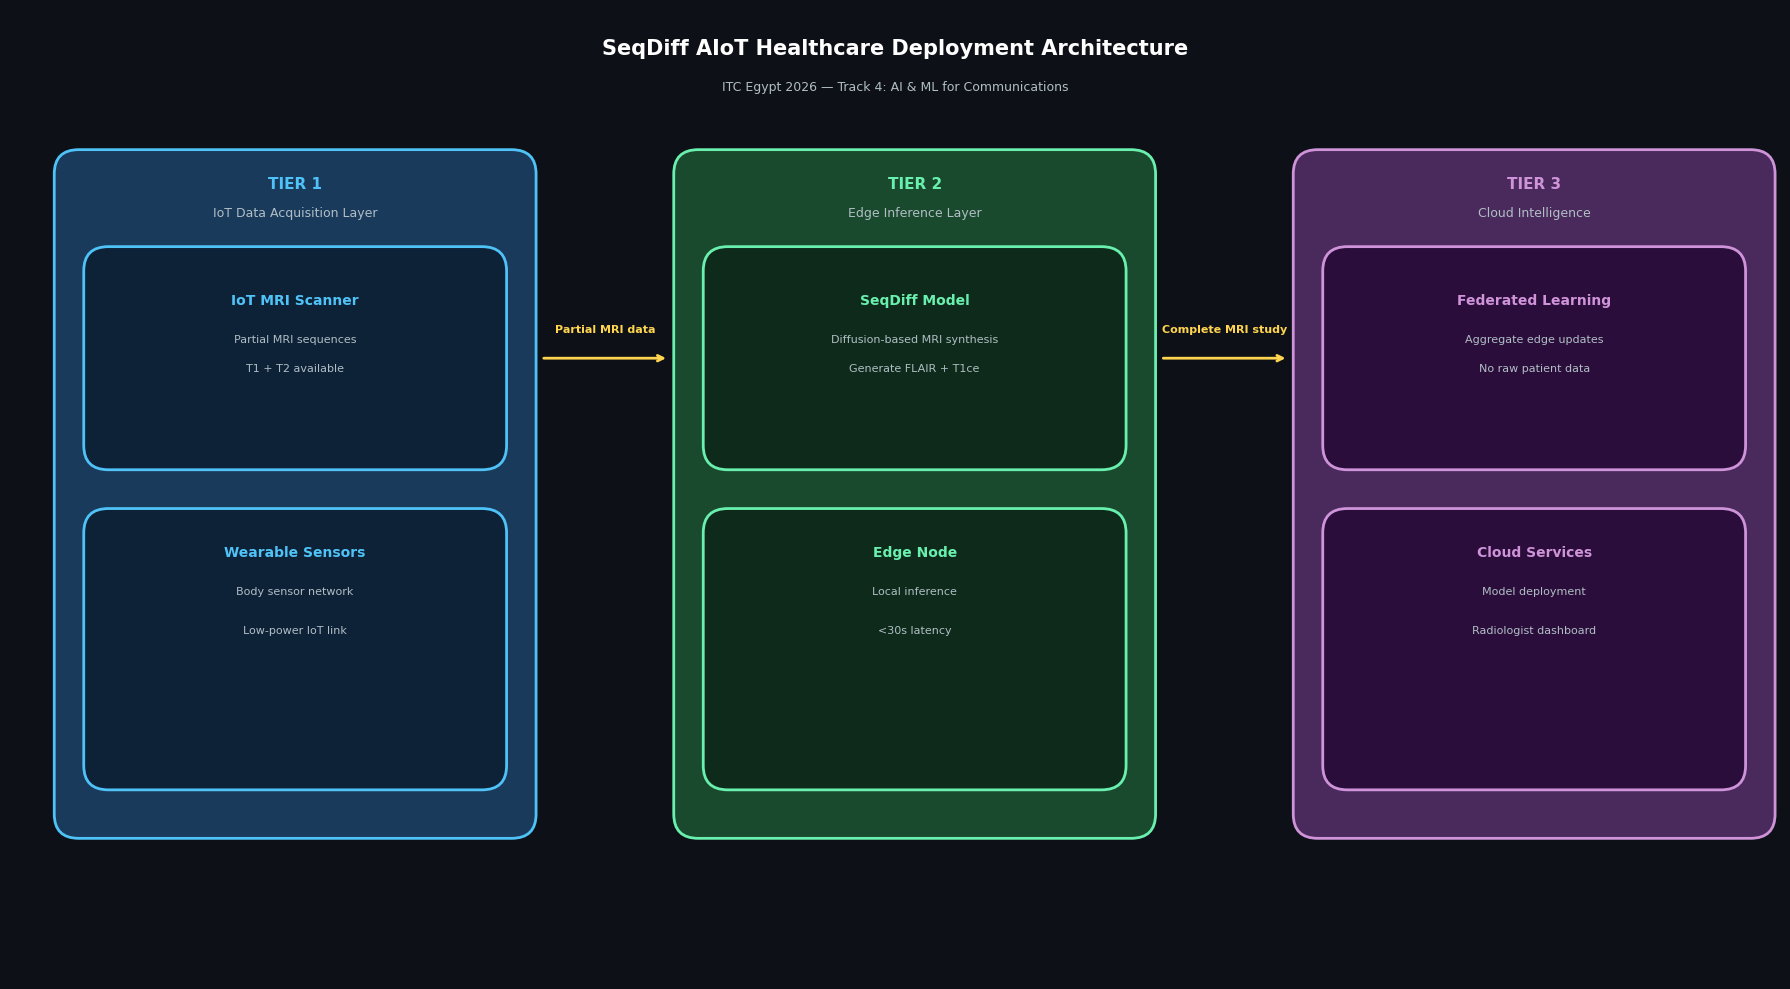

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(18,10))
ax.set_xlim(0,18)
ax.set_ylim(0,10)
ax.axis("off")

fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Colors
C_TIER1='#1a3a5c'
C_TIER2='#1a4a2e'
C_TIER3='#4a2a5c'

C_BORDER1='#4fc3f7'
C_BORDER2='#69f0ae'
C_BORDER3='#ce93d8'

TEXT='white'
SUB='#b0bec5'
ARROW='#ffd54f'

def box(x,y,w,h,fc,ec):
    rect=FancyBboxPatch(
        (x,y),w,h,
        boxstyle="round,pad=0.05,rounding_size=0.25",
        facecolor=fc,
        edgecolor=ec,
        linewidth=2
    )
    ax.add_patch(rect)

def label(cx,cy,text,size=9,color=TEXT,weight=None):
    ax.text(cx,cy,text,
            ha="center",va="center",
            fontsize=size,
            color=color,
            fontweight=weight)

# Layout
tier_w=4.8
tier_h=7

tier_y=1.5
gap=1.5

x1=0.5
x2=x1+tier_w+gap
x3=x2+tier_w+gap

c1=x1+tier_w/2
c2=x2+tier_w/2
c3=x3+tier_w/2

# Title
label(9,9.6,"SeqDiff AIoT Healthcare Deployment Architecture",15,TEXT,"bold")
label(9,9.2,"ITC Egypt 2026 — Track 4: AI & ML for Communications",9,SUB)

# Tiers
box(x1,tier_y,tier_w,tier_h,C_TIER1,C_BORDER1)
box(x2,tier_y,tier_w,tier_h,C_TIER2,C_BORDER2)
box(x3,tier_y,tier_w,tier_h,C_TIER3,C_BORDER3)

label(c1,8.2,"TIER 1",11,C_BORDER1,"bold")
label(c1,7.9,"IoT Data Acquisition Layer",9,SUB)

label(c2,8.2,"TIER 2",11,C_BORDER2,"bold")
label(c2,7.9,"Edge Inference Layer",9,SUB)

label(c3,8.2,"TIER 3",11,C_BORDER3,"bold")
label(c3,7.9,"Cloud Intelligence",9,SUB)

# Tier 1 Boxes
box(x1+0.3,5.3,4.2,2.2,"#0d2137",C_BORDER1)
label(c1,7.0,"IoT MRI Scanner",10,C_BORDER1,"bold")
label(c1,6.6,"Partial MRI sequences",8,SUB)
label(c1,6.3,"T1 + T2 available",8,SUB)

box(x1+0.3,2.0,4.2,2.8,"#0d2137",C_BORDER1)
label(c1,4.4,"Wearable Sensors",10,C_BORDER1,"bold")
label(c1,4.0,"Body sensor network",8,SUB)
label(c1,3.6,"Low-power IoT link",8,SUB)

# Tier 2 Boxes
box(x2+0.3,5.3,4.2,2.2,"#0d2a1a",C_BORDER2)
label(c2,7.0,"SeqDiff Model",10,C_BORDER2,"bold")
label(c2,6.6,"Diffusion-based MRI synthesis",8,SUB)
label(c2,6.3,"Generate FLAIR + T1ce",8,SUB)

box(x2+0.3,2.0,4.2,2.8,"#0d2a1a",C_BORDER2)
label(c2,4.4,"Edge Node",10,C_BORDER2,"bold")
label(c2,4.0,"Local inference",8,SUB)
label(c2,3.6,"<30s latency",8,SUB)

# Tier 3 Boxes
box(x3+0.3,5.3,4.2,2.2,"#2a0d3a",C_BORDER3)
label(c3,7.0,"Federated Learning",10,C_BORDER3,"bold")
label(c3,6.6,"Aggregate edge updates",8,SUB)
label(c3,6.3,"No raw patient data",8,SUB)

box(x3+0.3,2.0,4.2,2.8,"#2a0d3a",C_BORDER3)
label(c3,4.4,"Cloud Services",10,C_BORDER3,"bold")
label(c3,4.0,"Model deployment",8,SUB)
label(c3,3.6,"Radiologist dashboard",8,SUB)

# Arrows
ax.annotate("",xy=(x2-0.1,6.4),xytext=(x1+tier_w+0.1,6.4),
arrowprops=dict(arrowstyle="->",color=ARROW,lw=2))

label((x1+tier_w+x2)/2,6.7,"Partial MRI data",8,ARROW,"bold")

ax.annotate("",xy=(x3-0.1,6.4),xytext=(x2+tier_w+0.1,6.4),
arrowprops=dict(arrowstyle="->",color=ARROW,lw=2))

label((x2+tier_w+x3)/2,6.7,"Complete MRI study",8,ARROW,"bold")

plt.tight_layout()
plt.show()

## 📊 Section 2.4 — Bandwidth & Transmission Analysis

The following code cell computes **real file-size statistics** directly from the BraTS dataset to quantify the transmission overhead saved by edge inference with SeqDiff.

The analysis reports:
- Per-sequence NIfTI file sizes (compressed and uncompressed)
- Full 4-sequence study size vs. 2-sequence partial transmission
- Absolute and percentage bandwidth savings
- Extrapolated savings across a realistic patient cohort

These numbers provide the quantitative grounding for the IoT deployment argument and map directly to **ITC Track 4, Subtopic 13: Performance, interoperability, and scalability challenges.**

📂 Scanning BraTS file sizes...

📊 MRI FILE SIZE ANALYSIS — BraTS 2021 (sample: 50 subjects)
Sequence      Compressed (MB)    Uncompressed (MB)
                   Mean ± Std           Mean ± Std
--------------------------------------------------
T1              2.5 ± 0.4 MB       35.7 ± 0.0 MB
T2              2.6 ± 0.4 MB       35.7 ± 0.0 MB
FLAIR           2.7 ± 0.4 MB       35.7 ± 0.0 MB
T1CE            2.8 ± 0.5 MB       35.7 ± 0.0 MB

💡 BANDWIDTH SAVINGS FROM EDGE INFERENCE (SeqDiff)
  Full 4-seq study (T1+T2+FLAIR+T1ce): 10.5 MB
  Partial transmission (T1+T2 only):    5.0 MB
  Sequences synthesised at edge:         5.5 MB equivalent
  ✅ Bandwidth saving:  5.5 MB  (51.9%) per study

  📈 Cohort-Level Extrapolation:
         10 patients →     0.05 GB saved
        100 patients →     0.53 GB saved
       1000 patients →     5.33 GB saved
      10000 patients →    53.28 GB saved


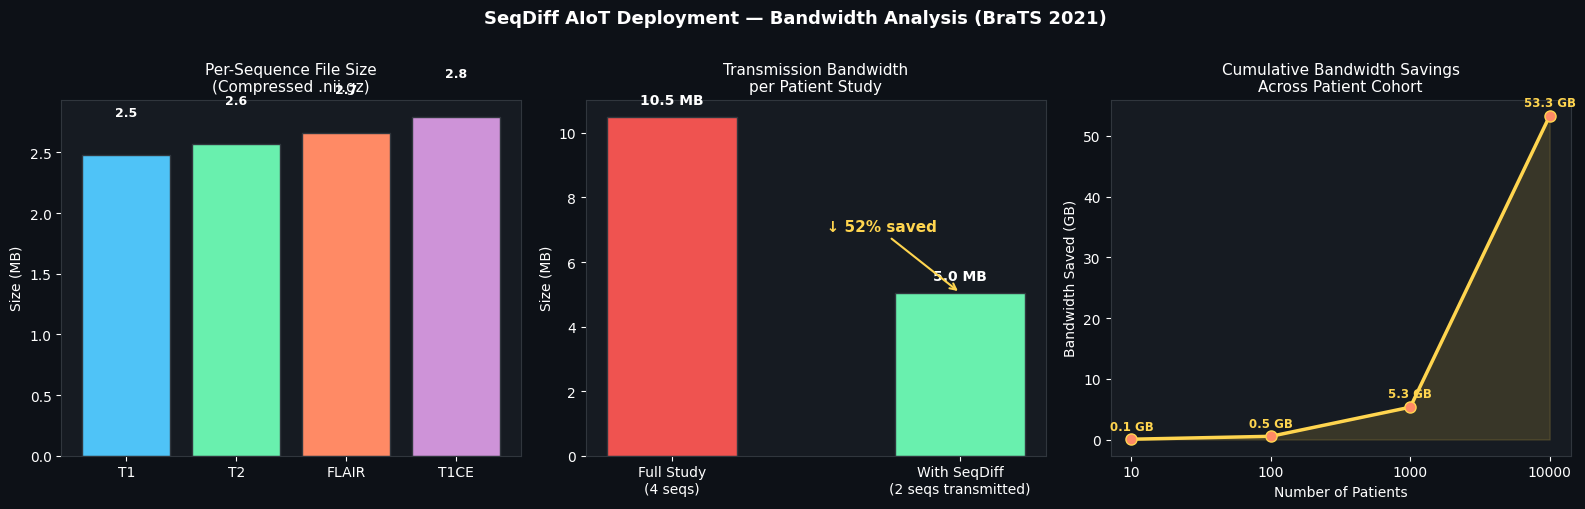

✅ Bandwidth analysis complete and figure saved.


In [9]:
# ============================================================
# BANDWIDTH ANALYSIS: Real NIfTI file size computation
# Quantifies transmission savings from edge inference (SeqDiff)
# Maps to: ITC Track 4 Subtopic 13 — Performance & Scalability
# ============================================================
import os, glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# DATA_PATH: use CFG if available, otherwise fall back to default path
try:
    DATA_PATH = CFG['data_path']
except NameError:
    DATA_PATH = '/kaggle/working/brats_extracted'
SEQS = ['t1', 't2', 'flair', 't1ce']

# ── 1. Collect file sizes ─────────────────────────────────
subject_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_PATH, 'BraTS2021_*'))
    if os.path.isdir(d)
])[:50]  # sample 50 subjects for speed

seq_sizes_compressed   = {s: [] for s in SEQS}  # .nii.gz on disk (bytes)
seq_sizes_uncompressed = {s: [] for s in SEQS}  # in-memory array (bytes)

print('📂 Scanning BraTS file sizes...')
for subj_dir in subject_dirs:
    for seq in SEQS:
        pattern = str(Path(subj_dir) / f'*_{seq}.nii.gz')
        files   = glob.glob(pattern)
        if not files:
            continue
        fpath = files[0]
        # Compressed size (actual disk / network payload)
        compressed_bytes = os.path.getsize(fpath)
        seq_sizes_compressed[seq].append(compressed_bytes)
        # Uncompressed array size (raw float32 volume)
        vol = nib.load(fpath).get_fdata(dtype=np.float32)
        seq_sizes_uncompressed[seq].append(vol.nbytes)

# ── 2. Compute summary statistics ────────────────────────
print('\n' + '='*65)
print('📊 MRI FILE SIZE ANALYSIS — BraTS 2021 (sample: 50 subjects)')
print('='*65)
print(f"{'Sequence':<10} {'Compressed (MB)':>18} {'Uncompressed (MB)':>20}")
print(f"{'':10} {'Mean ± Std':>18} {'Mean ± Std':>20}")
print('-'*50)

mean_comp   = {}
mean_uncomp = {}
for seq in SEQS:
    if not seq_sizes_compressed[seq]:
        continue
    c  = np.array(seq_sizes_compressed[seq])   / 1e6  # bytes → MB
    u  = np.array(seq_sizes_uncompressed[seq]) / 1e6
    mean_comp[seq]   = c.mean()
    mean_uncomp[seq] = u.mean()
    print(f"{seq.upper():<10} {c.mean():>8.1f} ± {c.std():.1f} MB   "
          f"{u.mean():>8.1f} ± {u.std():.1f} MB")

# ── 3. Bandwidth savings calculation ─────────────────────
all_seqs   = [s for s in SEQS if s in mean_comp]
full_study = sum(mean_comp[s] for s in all_seqs)

# SeqDiff scenario: transmit only T1+T2, synthesise FLAIR+T1ce at edge
partial_tx  = mean_comp.get('t1', 0) + mean_comp.get('t2', 0)
synthesised = mean_comp.get('flair', 0) + mean_comp.get('t1ce', 0)
saving_abs  = full_study - partial_tx
saving_pct  = (saving_abs / full_study) * 100

print('\n' + '='*65)
print('💡 BANDWIDTH SAVINGS FROM EDGE INFERENCE (SeqDiff)')
print('='*65)
print(f"  Full 4-seq study (T1+T2+FLAIR+T1ce): {full_study:.1f} MB")
print(f"  Partial transmission (T1+T2 only):    {partial_tx:.1f} MB")
print(f"  Sequences synthesised at edge:         {synthesised:.1f} MB equivalent")
print(f"  ✅ Bandwidth saving:  {saving_abs:.1f} MB  ({saving_pct:.1f}%) per study")

# ── 4. Cohort-level extrapolation ────────────────────────
print('\n  📈 Cohort-Level Extrapolation:')
for n_patients in [10, 100, 1000, 10000]:
    saved_gb = (saving_abs * n_patients) / 1024
    print(f"     {n_patients:>6} patients → {saved_gb:>8.2f} GB saved")

# ── 5. Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('#30363d')
    ax.yaxis.label.set_color('white')
    ax.xaxis.label.set_color('white')
    ax.title.set_color('white')

colors_seq = ['#4fc3f7', '#69f0ae', '#ff8a65', '#ce93d8']

# Plot A — Per-sequence compressed size
seqs_present = [s for s in SEQS if s in mean_comp]
vals_c = [mean_comp[s] for s in seqs_present]
bars = axes[0].bar([s.upper() for s in seqs_present], vals_c,
                   color=colors_seq[:len(seqs_present)], edgecolor='#30363d')
axes[0].set_title('Per-Sequence File Size\n(Compressed .nii.gz)', fontsize=11)
axes[0].set_ylabel('Size (MB)')
for bar, val in zip(bars, vals_c):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom',
                 fontsize=9, color='white', fontweight='bold')

# Plot B — Transmission comparison
scenarios = ['Full Study\n(4 seqs)', 'With SeqDiff\n(2 seqs transmitted)']
vals_b    = [full_study, partial_tx]
bar_colors = ['#ef5350', '#69f0ae']
bars2 = axes[1].bar(scenarios, vals_b, color=bar_colors, edgecolor='#30363d', width=0.45)
axes[1].set_title('Transmission Bandwidth\nper Patient Study', fontsize=11)
axes[1].set_ylabel('Size (MB)')
for bar, val in zip(bars2, vals_b):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f} MB', ha='center', va='bottom',
                 fontsize=10, color='white', fontweight='bold')
axes[1].annotate(f'  ↓ {saving_pct:.0f}% saved',
                 xy=(1, partial_tx), xytext=(0.5, partial_tx + saving_abs*0.35),
                 fontsize=11, color='#ffd54f', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#ffd54f', lw=1.5))

# Plot C — Cohort savings
n_list  = [10, 100, 1000, 10000]
gb_list = [(saving_abs * n) / 1024 for n in n_list]
axes[2].plot([str(n) for n in n_list], gb_list,
             marker='o', color='#ffd54f', linewidth=2.5,
             markersize=8, markerfacecolor='#ff8a65')
axes[2].fill_between(range(len(n_list)), gb_list, alpha=0.15, color='#ffd54f')
axes[2].set_title('Cumulative Bandwidth Savings\nAcross Patient Cohort', fontsize=11)
axes[2].set_xlabel('Number of Patients')
axes[2].set_ylabel('Bandwidth Saved (GB)')
for i, (x, y) in enumerate(zip(range(len(n_list)), gb_list)):
    axes[2].text(x, y + max(gb_list)*0.03, f'{y:.1f} GB',
                 ha='center', fontsize=8.5, color='#ffd54f', fontweight='bold')

plt.suptitle('SeqDiff AIoT Deployment — Bandwidth Analysis (BraTS 2021)',
             fontsize=13, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/bandwidth_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Bandwidth analysis complete and figure saved.')

### Model Architecture Building

In [10]:
# ── a. Sequence-Agnostic Cross-Attention Encoder ───────────────────────────
class SequenceAgnosticEncoder(nn.Module):
    """
    Novel: handles variable number of input sequences via cross-attention.
    Prior work uses fixed concatenation — this is more flexible & generalizable.
    """
    def __init__(self, in_ch_per_seq=1, base_ch=64, out_ch=128):
        super().__init__()
        self.seq_conv = nn.Sequential(
            nn.Conv2d(in_ch_per_seq, base_ch, 3, padding=1),
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.GroupNorm(8, base_ch),
            nn.SiLU(),
        )
        self.attn       = nn.MultiheadAttention(base_ch, num_heads=8, batch_first=True)
        # Learnable linear to produce per-sequence scalar fusion score
        self.weight_proj = nn.Linear(base_ch, 1)
        self.out_proj = nn.Sequential(
            nn.Conv2d(base_ch, out_ch, 1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )

    def forward(self, x):
        # x: [B, N_seq, H, W]  — N_seq variable
        B, N, H, W = x.shape
        # Encode each sequence independently
        seqs = x.view(B * N, 1, H, W)
        feats = self.seq_conv(seqs)           # [B*N, base_ch, H, W]
        C = feats.shape[1]
        feats = feats.view(B, N, C, H * W)   # [B, N, C, H*W]

        # Self-attention across sequence tokens to capture inter-sequence context
        # q = mean-pooled feature vector per sequence: [B, N, C]
        q = feats.mean(-1)                        # [B, N, C]
        attn_out, _ = self.attn(q, q, q)          # [B, N, C]  (softmax already inside)
        # Project attended features → per-sequence scalar score, then normalize
        # FIX: removed redundant torch.softmax(attn_out) — MHA already applies softmax
        #      internally; applying softmax again destroyed the learned weights.
        scores  = self.weight_proj(attn_out)      # [B, N, 1]
        weights = torch.softmax(scores, dim=1)    # [B, N, 1]  — normalize over N seqs

        # Weighted sum of sequence features
        weights = weights.unsqueeze(-1)           # [B, N, 1, 1]
        fused = (feats * weights).sum(dim=1)      # [B, C, H*W]
        fused = fused.view(B, C, H, W)
        return self.out_proj(fused)               # [B, out_ch, H, W]


# ── b. Target Sequence Token Embedding ─────────────────────────────────────
class SequenceTokenEmbedding(nn.Module):
    """Learnable embedding for target sequence — enables sequence conditioning."""
    def __init__(self, n_seqs=4, embed_dim=256):
        super().__init__()
        self.embed = nn.Embedding(n_seqs, embed_dim)

    def forward(self, seq_id):
        return self.embed(seq_id)    # [B, embed_dim]


# ── c. Sinusoidal Timestep Embedding ───────────────────────────────────────
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        emb    = torch.log(torch.tensor(10000.0)) / (half - 1)
        emb    = torch.exp(torch.arange(half, device=device) * -emb)
        emb    = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)   # [B, dim]


# ── d. ResBlock with conditioning ──────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, cond_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act   = nn.SiLU()

        # Time and sequence conditioning projections
        self.time_proj = nn.Linear(time_dim, out_ch * 2)
        self.cond_proj = nn.Linear(cond_dim, out_ch * 2)

        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, cond_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)

        # Inject time embedding (scale + shift)
        t  = self.time_proj(self.act(t_emb))[:, :, None, None]
        ts, tb = t.chunk(2, dim=1)
        h  = h * (1 + ts) + tb

        # Inject sequence conditioning
        c  = self.cond_proj(self.act(cond_emb))[:, :, None, None]
        cs, cb = c.chunk(2, dim=1)
        h  = h * (1 + cs) + cb

        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.res_conv(x)


# ── e. Full Diffusion U-Net ────────────────────────────────────────────────
class MRIDiffusionUNet(nn.Module):
    """
    Conditioned on:
      1. Spatial features from SequenceAgnosticEncoder (skip connections)
      2. Target sequence token (global conditioning)
      3. Diffusion timestep embedding
    """
    def __init__(self, in_ch=1, base_ch=64, time_dim=256,
                 seq_embed_dim=256, encoder_out_ch=128, n_seqs=4):
        super().__init__()
        ch = base_ch
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        self.seq_embed = SequenceTokenEmbedding(n_seqs, seq_embed_dim)
        self.encoder   = SequenceAgnosticEncoder(1, ch, encoder_out_ch)

        # Merge condition dims
        cond_dim = seq_embed_dim

        # Encoder path
        self.init_conv  = nn.Conv2d(in_ch + encoder_out_ch, ch, 3, padding=1)
        self.enc1 = ResBlock(ch,    ch*2,  time_dim, cond_dim)
        self.down1 = nn.Conv2d(ch*2, ch*2, 4, stride=2, padding=1)
        self.enc2 = ResBlock(ch*2,  ch*4,  time_dim, cond_dim)
        self.down2 = nn.Conv2d(ch*4, ch*4, 4, stride=2, padding=1)
        self.enc3 = ResBlock(ch*4,  ch*8,  time_dim, cond_dim)
        self.down3 = nn.Conv2d(ch*8, ch*8, 4, stride=2, padding=1)

        # Bottleneck
        self.mid1 = ResBlock(ch*8, ch*8, time_dim, cond_dim)
        self.mid2 = ResBlock(ch*8, ch*8, time_dim, cond_dim)

        # Decoder path
        self.up3   = nn.ConvTranspose2d(ch*8, ch*8, 4, stride=2, padding=1)
        self.dec3  = ResBlock(ch*16, ch*4, time_dim, cond_dim)
        self.up2   = nn.ConvTranspose2d(ch*4, ch*4, 4, stride=2, padding=1)
        self.dec2  = ResBlock(ch*8,  ch*2, time_dim, cond_dim)
        self.up1   = nn.ConvTranspose2d(ch*2, ch*2, 4, stride=2, padding=1)
        self.dec1  = ResBlock(ch*4,  ch,   time_dim, cond_dim)

        self.out_norm = nn.GroupNorm(8, ch)
        self.out_conv = nn.Conv2d(ch, in_ch, 1)

    def forward(self, x_noisy, t, input_seqs, target_seq_id):
        """
        x_noisy     : [B, 1, H, W]  — noisy target
        t           : [B]            — timestep
        input_seqs  : [B, N, H, W]  — available input sequences
        target_seq_id: [B]           — which sequence to generate
        """
        # Embeddings
        t_emb   = self.time_mlp(t)                    # [B, time_dim]
        seq_emb = self.seq_embed(target_seq_id)       # [B, seq_embed_dim]

        # Spatial conditioning from encoder
        spatial = self.encoder(input_seqs)            # [B, enc_out, H, W]

        # Concatenate spatial condition to noisy input
        x = self.init_conv(torch.cat([x_noisy, spatial], dim=1))

        # Encoder
        e1 = self.enc1(x,           t_emb, seq_emb)
        e2 = self.enc2(self.down1(e1), t_emb, seq_emb)
        e3 = self.enc3(self.down2(e2), t_emb, seq_emb)

        # Bottleneck
        m  = self.mid1(self.down3(e3), t_emb, seq_emb)
        m  = self.mid2(m,              t_emb, seq_emb)

        # Decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(m),  e3], dim=1), t_emb, seq_emb)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb, seq_emb)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb, seq_emb)

        return self.out_conv(F.silu(self.out_norm(d1)))

###  DDPM Noise Scheduler

In [11]:
class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T      = T
        self.device = device
        betas       = torch.linspace(beta_start, beta_end, T).to(device)
        alphas      = 1.0 - betas
        alpha_bar   = torch.cumprod(alphas, dim=0)

        self.register("betas",     betas)
        self.register("alphas",    alphas)
        self.register("alpha_bar", alpha_bar)
        self.register("sqrt_ab",   alpha_bar.sqrt())
        self.register("sqrt_1mab", (1 - alpha_bar).sqrt())

    def register(self, name, val):
        setattr(self, name, val)

    def add_noise(self, x0, noise, t):
        """Forward process: q(x_t | x_0)"""
        s1 = self.sqrt_ab[t][:, None, None, None]
        s2 = self.sqrt_1mab[t][:, None, None, None]
        return s1 * x0 + s2 * noise

    @torch.no_grad()
    def sample(self, model, input_seqs, target_seq_id, shape, device):
        """Reverse process: p(x_0 | x_T) — full denoising"""
        x = torch.randn(shape, device=device)
        for t_val in tqdm(reversed(range(self.T)), desc="Sampling", total=self.T, leave=False):
            t_batch = torch.full((shape[0],), t_val, device=device, dtype=torch.long)
            pred_noise = model(x, t_batch, input_seqs, target_seq_id)

            alpha     = self.alphas[t_val]
            alpha_bar = self.alpha_bar[t_val]
            beta      = self.betas[t_val]

            if t_val > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1 / alpha.sqrt()) * (
                x - (beta / (1 - alpha_bar).sqrt()) * pred_noise
            ) + beta.sqrt() * noise
        return x.clamp(0, 1)

    @torch.no_grad()
    def fast_sample(self, model, input_seqs, target_seq_id, shape, device, steps=50):
        """DDIM-style fast sampling — use for evaluation to save time"""
        x      = torch.randn(shape, device=device)
        t_seq  = torch.linspace(self.T - 1, 0, steps).long().to(device)
        for i, t_val in enumerate(tqdm(t_seq, desc="Fast Sampling", leave=False)):
            t_batch    = t_val.expand(shape[0])
            pred_noise = model(x, t_batch, input_seqs, target_seq_id)
            ab         = self.alpha_bar[t_val]
            x0_pred    = (x - (1 - ab).sqrt() * pred_noise) / ab.sqrt()
            x0_pred    = x0_pred.clamp(0, 1)
            if i < len(t_seq) - 1:
                ab_next = self.alpha_bar[t_seq[i + 1]]
                x = ab_next.sqrt() * x0_pred + (1 - ab_next).sqrt() * pred_noise
            else:
                x = x0_pred
        return x

### Baseline Models (Pix2Pix Generator)

In [12]:
class UNetBaseline(nn.Module):
    """Simple U-Net as Pix2Pix-style baseline — no diffusion, no conditioning"""
    def __init__(self, in_ch=2, out_ch=1, base_ch=64):
        super().__init__()
        def down_block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 4, stride=2, padding=1),
                nn.LeakyReLU(0.2),
                nn.BatchNorm2d(oc)
            )
        def up_block(ic, oc):
            return nn.Sequential(
                nn.ConvTranspose2d(ic, oc, 4, stride=2, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(oc)
            )
        self.e1 = down_block(in_ch, base_ch)
        self.e2 = down_block(base_ch,   base_ch*2)
        self.e3 = down_block(base_ch*2, base_ch*4)
        self.e4 = down_block(base_ch*4, base_ch*8)
        self.d4 = up_block(base_ch*8,   base_ch*4)
        self.d3 = up_block(base_ch*4*2, base_ch*2)
        self.d2 = up_block(base_ch*2*2, base_ch)
        self.d1 = up_block(base_ch*2,   base_ch)
        self.out = nn.Conv2d(base_ch, out_ch, 1)

    def forward(self, x, *args):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        d  = self.d4(e4)
        d  = self.d3(torch.cat([d, e3], 1))
        d  = self.d2(torch.cat([d, e2], 1))
        d  = self.d1(torch.cat([d, e1], 1))
        return torch.sigmoid(self.out(d))

### Model Training

In [13]:
def train_one_epoch(model, loader, optimizer, scheduler,
                    seq_tokens, cfg, epoch, scaler):
    """
    Single training epoch with:
    - AMP mixed precision (FP16) — ~2x throughput on Kaggle T4/P100
    - Gradient clipping
    - Proper scaler.step / scaler.update pattern
    """
    model.train()
    total_loss = 0
    device     = cfg["device"]
    target_seq = loader.dataset.target_seq
    target_id  = seq_tokens[target_seq]
    use_amp    = cfg.get("use_amp", True) and device == "cuda"

    for inputs, target in tqdm(loader, desc=f"Epoch {epoch}", leave=False):
        inputs = inputs.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        B      = inputs.shape[0]

        t              = torch.randint(0, cfg["T"], (B,), device=device)
        noise          = torch.randn_like(target)
        noisy_target   = scheduler.add_noise(target, noise, t)
        target_seq_ids = torch.full((B,), target_id, device=device, dtype=torch.long)

        optimizer.zero_grad()

        # ── AMP forward pass ─────────────────────────────────────────────────
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred_noise = model(noisy_target, t, inputs, target_seq_ids)
            loss       = F.mse_loss(pred_noise, noise)

        # ── AMP backward + step ──────────────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, scheduler, seq_tokens, cfg):
    model.eval()
    total_loss = 0
    device     = cfg["device"]
    target_seq = loader.dataset.target_seq
    target_id  = seq_tokens[target_seq]
    use_amp    = cfg.get("use_amp", True) and device == "cuda"

    for inputs, target in loader:
        inputs = inputs.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        B      = inputs.shape[0]
        t      = torch.randint(0, cfg["T"], (B,), device=device)
        noise  = torch.randn_like(target)
        noisy  = scheduler.add_noise(target, noise, t)
        ids    = torch.full((B,), target_id, device=device, dtype=torch.long)

        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(noisy, t, inputs, ids)
            total_loss += F.mse_loss(pred, noise).item()

    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, cfg,
                exp_name="t1t2_to_flair", use_wandb=False):
    device    = cfg["device"]
    scheduler = DDPMScheduler(cfg["T"], device=device)
    _use_fused = device == "cuda" and torch.cuda.is_available()
    optimizer  = torch.optim.AdamW(model.parameters(), lr=cfg["lr"],
                                   fused=_use_fused)
    lr_sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
                     optimizer, T_max=cfg["epochs"])

    # AMP gradient scaler — does nothing if use_amp=False
    scaler = torch.cuda.amp.GradScaler(
        enabled=cfg.get("use_amp", True) and device == "cuda"
    )

    if use_wandb:
        wandb.init(project="zero-shot-mri-synthesis", name=exp_name, config=cfg)

    best_val   = float("inf")
    best_path  = os.path.join(cfg["save_dir"], f"best_{exp_name}.pt")
    history    = {"train_loss": [], "val_loss": []}

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = __import__("time").time()

        train_loss = train_one_epoch(
            model, train_loader, optimizer, scheduler,
            cfg["seq_tokens"], cfg, epoch, scaler   # ← scaler passed in
        )
        val_loss = validate(model, val_loader, scheduler, cfg["seq_tokens"], cfg)
        lr_sched.step()

        elapsed = __import__("time").time() - t0
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if use_wandb:
            wandb.log({"train_loss": train_loss, "val_loss": val_loss,
                       "epoch": epoch, "epoch_time_s": elapsed})

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), best_path)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{cfg['epochs']} | "
                  f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                  f"Best: {best_val:.4f} | {elapsed:.0f}s/ep")

    print(f"\n✅ Training done. Best val loss: {best_val:.4f}")
    print(f"   Checkpoint: {best_path}")
    return history, best_path


### Model Evaluation Matrics

In [14]:
# LPIPS (Learned Perceptual Image Patch Similarity) — returns a continuous
# perceptual distance float in [0, ∞), NOT a binary 0/1 value.
# Lower = more perceptually similar. This is correct usage.
loss_fn_lpips = lpips.LPIPS(net="alex").to(CFG["device"])

@torch.no_grad()
def evaluate_model(model, test_loader, scheduler, cfg,
                   n_sample_steps=50, max_batches=20):
    """
    Returns dict of SSIM, PSNR, LPIPS averaged over test set.
    Uses fast_sample (DDIM) for speed.
    """
    model.eval()
    device     = cfg["device"]
    target_seq = test_loader.dataset.target_seq
    target_id  = cfg["seq_tokens"][target_seq]

    ssim_vals, psnr_vals, lpips_vals = [], [], []

    for i, (inputs, target) in enumerate(
            tqdm(test_loader, desc="Evaluating", total=min(max_batches, len(test_loader)))):
        if i >= max_batches:
            break
        inputs = inputs.to(device)
        target = target.to(device)
        B      = inputs.shape[0]
        ids    = torch.full((B,), target_id, device=device, dtype=torch.long)

        # Generate synthetic image
        preds  = scheduler.fast_sample(
            model, inputs, ids,
            shape=(B, 1, cfg["img_size"], cfg["img_size"]),
            device=device, steps=n_sample_steps
        )

        # Compute metrics per sample
        for b in range(B):
            p = preds[b, 0].cpu().numpy()
            t = target[b, 0].cpu().numpy()
            ssim_vals.append(ssim(t, p, data_range=1.0))
            psnr_vals.append(psnr(t, p, data_range=1.0))

        # LPIPS on batch
        lp = loss_fn_lpips(
            preds.repeat(1, 3, 1, 1),
            target.repeat(1, 3, 1, 1)
        )
        lpips_vals.extend(lp.squeeze().cpu().tolist()
                          if B > 1 else [lp.item()])

    return {
        "SSIM" : np.mean(ssim_vals),
        "PSNR" : np.mean(psnr_vals),
        "LPIPS": np.mean(lpips_vals),
        "SSIM_std" : np.std(ssim_vals),
        "PSNR_std" : np.std(psnr_vals),
    }

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 170MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


### Model Qualitative Visualization

In [15]:
@torch.no_grad()
def visualize_results(model, test_loader, scheduler, cfg,
                      n_cases=3, n_sample_steps=50,
                      save_path=None):
    model.eval()
    device     = cfg["device"]
    target_seq = test_loader.dataset.target_seq
    target_id  = cfg["seq_tokens"][target_seq]
    input_seqs = test_loader.dataset.input_seqs

    inputs_list, target_list, pred_list = [], [], []
    for inputs, target in test_loader:
        inputs = inputs.to(device)
        target = target.to(device)
        B      = inputs.shape[0]
        ids    = torch.full((B,), target_id, device=device, dtype=torch.long)
        preds  = scheduler.fast_sample(
            model, inputs, ids,
            shape=(B, 1, cfg["img_size"], cfg["img_size"]),
            device=device, steps=n_sample_steps
        )
        inputs_list.append(inputs.cpu())
        target_list.append(target.cpu())
        pred_list.append(preds.cpu())
        if len(inputs_list) * B >= n_cases:
            break

    inputs_all = torch.cat(inputs_list)[:n_cases]
    target_all = torch.cat(target_list)[:n_cases]
    pred_all   = torch.cat(pred_list)[:n_cases]

    n_input_cols = inputs_all.shape[1]
    n_cols       = n_input_cols + 3   # inputs | real | pred | diff_map
    fig, axes    = plt.subplots(n_cases, n_cols, figsize=(n_cols * 3, n_cases * 3))
    if n_cases == 1:
        axes = axes[np.newaxis]

    for row in range(n_cases):
        col = 0
        for s in range(n_input_cols):
            axes[row, col].imshow(inputs_all[row, s].numpy(), cmap="gray")
            axes[row, col].set_title(input_seqs[s].upper(), fontsize=9)
            axes[row, col].axis("off")
            col += 1

        axes[row, col].imshow(target_all[row, 0].numpy(), cmap="gray")
        axes[row, col].set_title(f"Real {target_seq.upper()}", fontsize=9)
        axes[row, col].axis("off")
        col += 1

        axes[row, col].imshow(pred_all[row, 0].numpy(), cmap="gray")
        axes[row, col].set_title(f"Predicted {target_seq.upper()}", fontsize=9)
        axes[row, col].axis("off")
        col += 1

        diff = torch.abs(target_all[row, 0] - pred_all[row, 0]).numpy()
        axes[row, col].imshow(diff, cmap="hot", vmin=0, vmax=0.3)
        axes[row, col].set_title("Error Map", fontsize=9)
        axes[row, col].axis("off")

    plt.suptitle(f"MRI Synthesis: {'+'.join(input_seqs).upper()} → {target_seq.upper()}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

### Ablation Study Setup

In [16]:
class AblationModel_NoAttn(nn.Module):
    """Ablation: replace cross-attention with simple concatenation"""
    def __init__(self, in_ch_total=2, base_ch=64, time_dim=256,
                 seq_embed_dim=256, n_seqs=4):
        super().__init__()
        # Simple concatenation instead of cross-attention
        self.time_mlp  = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 4), nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        self.seq_embed = SequenceTokenEmbedding(n_seqs, seq_embed_dim)
        ch = base_ch
        cond_dim = seq_embed_dim
        self.init_conv  = nn.Conv2d(1 + in_ch_total, ch, 3, padding=1)
        self.enc1 = ResBlock(ch,    ch*2, time_dim, cond_dim)
        self.down1 = nn.Conv2d(ch*2, ch*2, 4, stride=2, padding=1)
        self.enc2 = ResBlock(ch*2,  ch*4, time_dim, cond_dim)
        self.down2 = nn.Conv2d(ch*4, ch*4, 4, stride=2, padding=1)
        self.mid  = ResBlock(ch*4, ch*4, time_dim, cond_dim)
        self.up2  = nn.ConvTranspose2d(ch*4, ch*2, 4, stride=2, padding=1)
        self.dec2 = ResBlock(ch*2+ch*4, ch*2, time_dim, cond_dim)
        self.up1  = nn.ConvTranspose2d(ch*2, ch,   4, stride=2, padding=1)
        self.dec1 = ResBlock(ch+ch*2, ch,   time_dim, cond_dim)
        self.out  = nn.Conv2d(ch, 1, 1)

    def forward(self, x_noisy, t, input_seqs, target_seq_id):
        t_emb   = self.time_mlp(t)
        seq_emb = self.seq_embed(target_seq_id)
        # Concatenation fusion (no attention)
        spatial = input_seqs.mean(dim=1, keepdim=True)  # average channels
        x = self.init_conv(torch.cat([x_noisy, input_seqs], dim=1))
        e1 = self.enc1(x,           t_emb, seq_emb)
        e2 = self.enc2(self.down1(e1), t_emb, seq_emb)
        m  = self.mid(self.down2(e2),  t_emb, seq_emb)
        d2 = self.dec2(torch.cat([self.up2(m),  e2], dim=1), t_emb, seq_emb)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb, seq_emb)
        return self.out(d1)

### Main Run Experiments Function

In [17]:
def run_experiment(input_seqs, target_seq, cfg, exp_tag=None, use_wandb=False):
    if exp_tag is None:
        exp_tag = f"{'_'.join(input_seqs)}_to_{target_seq}"

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {'+'.join(s.upper() for s in input_seqs)} → {target_seq.upper()}")
    print(f"{'='*60}")

    # Data
    train_loader, val_loader, test_loader, _ = make_loaders(
        cfg["data_path"], input_seqs, target_seq, cfg
    )

    # Model
    model = MRIDiffusionUNet(
        in_ch=1, base_ch=64, time_dim=256,
        seq_embed_dim=256, encoder_out_ch=128, n_seqs=4
    ).to(cfg["device"])

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model parameters: {n_params:,}")

    # Train
    history, best_ckpt = train_model(
        model, train_loader, val_loader, cfg,
        exp_name=exp_tag, use_wandb=use_wandb
    )

    # Load best checkpoint
    model.load_state_dict(torch.load(best_ckpt))

    # Evaluate
    scheduler = DDPMScheduler(cfg["T"], device=cfg["device"])
    metrics   = evaluate_model(model, test_loader, scheduler, cfg)
    print(f"\n📊 Test Results — {exp_tag}")
    for k, v in metrics.items():
        print(f"   {k}: {v:.4f}")

    # Visualize
    fig_path = os.path.join(cfg["results_dir"], f"qual_{exp_tag}.png")
    visualize_results(model, test_loader, scheduler, cfg, save_path=fig_path)

    # Loss curves
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Training Curves — {exp_tag}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(cfg["results_dir"], f"loss_{exp_tag}.png"), dpi=100)
    plt.show()

    return model, metrics, history

### ABLATION RUNNER

In [18]:
def run_ablations(input_seqs, target_seq, cfg, trained_model=None):
    """
    Runs ablation studies comparing your full model vs variants.
    Train a few epochs each (not full 100) to show relative performance.
    """
    ABLATION_EPOCHS = 20   # fast ablations
    cfg_abl = {**cfg, "epochs": ABLATION_EPOCHS}

    train_loader, val_loader, test_loader, _ = make_loaders(
        cfg["data_path"], input_seqs, target_seq, cfg
    )
    scheduler = DDPMScheduler(cfg["T"], device=cfg["device"])
    results   = {}

    ablations = {
        "Full Model (Ours)": MRIDiffusionUNet(n_seqs=4).to(cfg["device"]),
        "w/o Cross-Attention": AblationModel_NoAttn(
            in_ch_total=len(input_seqs)).to(cfg["device"]),
        "Baseline U-Net": UNetBaseline(
            in_ch=len(input_seqs)).to(cfg["device"]),
    }

    for name, model in ablations.items():
        print(f"\n🔬 Ablation: {name}")
        _, ckpt = train_model(
            model, train_loader, val_loader, cfg_abl,
            exp_name=f"ablation_{name.replace(' ', '_').replace('/', '_')}"
        )
        model.load_state_dict(torch.load(ckpt))
        m = evaluate_model(model, test_loader, scheduler, cfg, max_batches=10)
        results[name] = m
        print(f"   SSIM: {m['SSIM']:.4f} | PSNR: {m['PSNR']:.4f} | LPIPS: {m['LPIPS']:.4f}")

    # Print ablation table
    print(f"\n{'='*60}")
    print("ABLATION TABLE")
    print(f"{'Method':<30} {'SSIM':>8} {'PSNR':>8} {'LPIPS':>8}")
    print("-" * 58)
    for name, m in results.items():
        marker = " ← OURS" if name == "Full Model (Ours)" else ""
        print(f"{name:<30} {m['SSIM']:>8.4f} {m['PSNR']:>8.2f} {m['LPIPS']:>8.4f}{marker}")

    return results

### Main Running Cell


EXPERIMENT: T1+T2 → FLAIR
Train/Val/Test subjects: 150/20/30
Train slices: 3,000 | Val: 400 | Test: 600
Model parameters: 32,596,610


  Epoch   1/100 | Train: 0.1453 | Val: 0.0160 | Best: 0.0160 | 80s/ep


  Epoch   5/100 | Train: 0.0084 | Val: 0.0064 | Best: 0.0064 | 76s/ep


  Epoch  10/100 | Train: 0.0076 | Val: 0.0065 | Best: 0.0053 | 76s/ep


  Epoch  15/100 | Train: 0.0066 | Val: 0.0068 | Best: 0.0053 | 76s/ep


...

  Epoch  95/100 | Train: 0.0034 | Val: 0.0038 | Best: 0.0024 | 76s/ep


  Epoch 100/100 | Train: 0.0031 | Val: 0.0045 | Best: 0.0024 | 77s/ep

✅ Training done. Best val loss: 0.0024
   Checkpoint: /kaggle/working/checkpoints/best_t1t2_to_flair.pt


Evaluating: 100%|██████████| 20/20 [02:06<00:00,  6.31s/it]



📊 Test Results — t1t2_to_flair
   SSIM: 0.1561
   PSNR: 11.7670
   LPIPS: 0.1879
   SSIM_std: 0.0395
   PSNR_std: 1.4578


Saved: /kaggle/working/results/qual_t1t2_to_flair.png


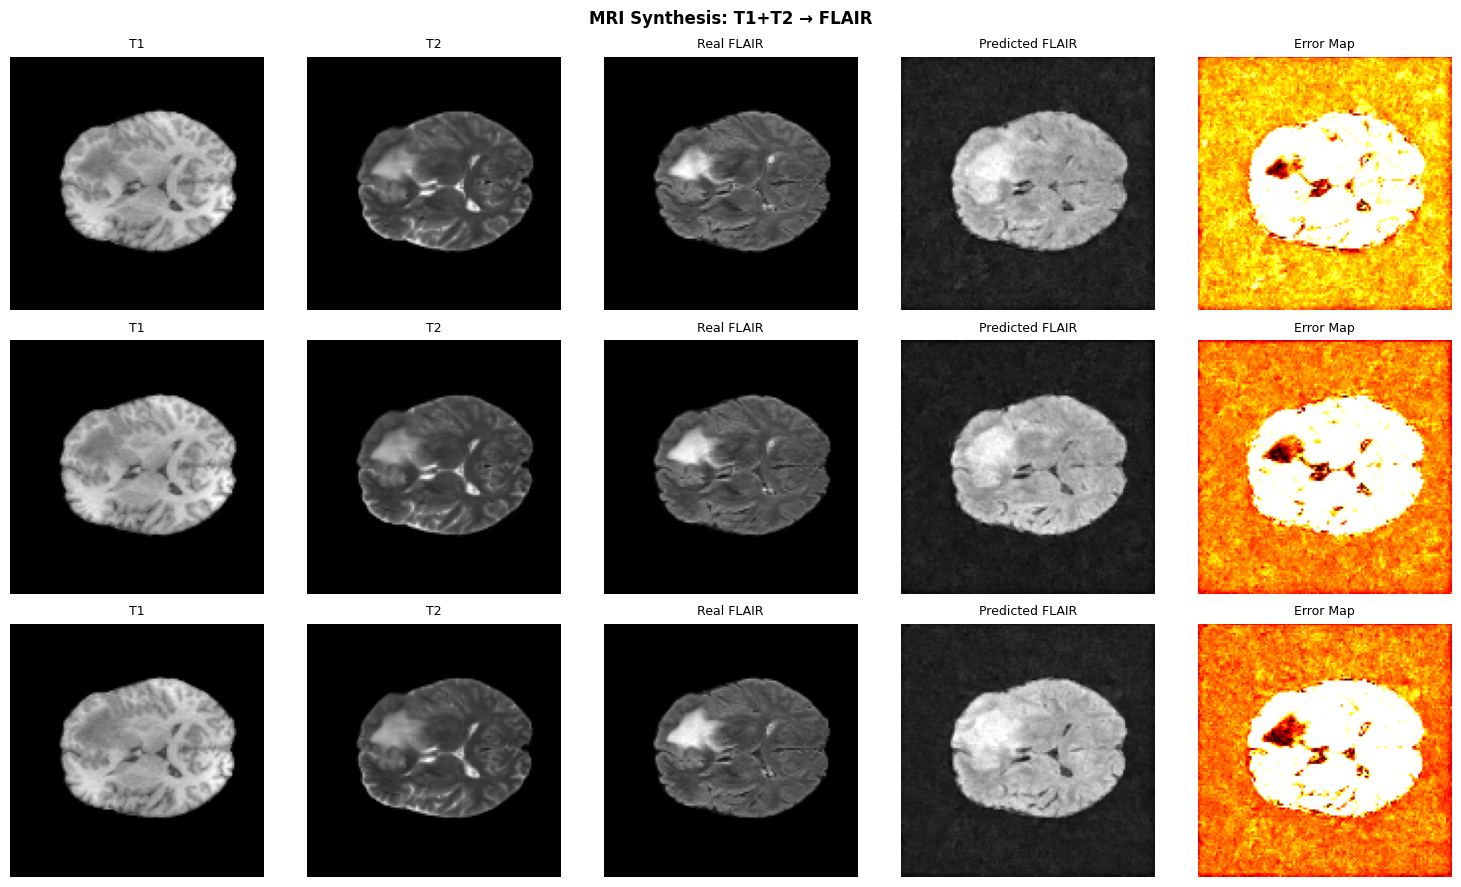

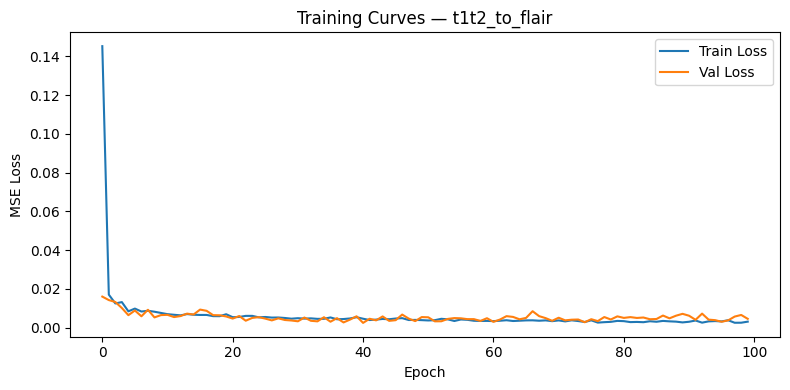


EXPERIMENT: T1+FLAIR → T2
Train/Val/Test subjects: 150/20/30
Train slices: 3,000 | Val: 400 | Test: 600
Model parameters: 32,596,610


  Epoch   1/100 | Train: 0.1238 | Val: 0.0194 | Best: 0.0194 | 77s/ep


  Epoch   5/100 | Train: 0.0099 | Val: 0.0082 | Best: 0.0082 | 76s/ep


  Epoch  10/100 | Train: 0.0076 | Val: 0.0052 | Best: 0.0052 | 77s/ep


  Epoch  15/100 | Train: 0.0060 | Val: 0.0041 | Best: 0.0041 | 76s/ep


...

  Epoch  95/100 | Train: 0.0023 | Val: 0.0036 | Best: 0.0028 | 76s/ep


  Epoch 100/100 | Train: 0.0021 | Val: 0.0046 | Best: 0.0028 | 76s/ep

✅ Training done. Best val loss: 0.0028
   Checkpoint: /kaggle/working/checkpoints/best_t1_flair_to_t2.pt


Evaluating: 100%|██████████| 20/20 [02:05<00:00,  6.26s/it]



📊 Test Results — t1_flair_to_t2
   SSIM: 0.2197
   PSNR: 13.2165
   LPIPS: 0.1012
   SSIM_std: 0.0384
   PSNR_std: 0.6725


Saved: /kaggle/working/results/qual_t1_flair_to_t2.png


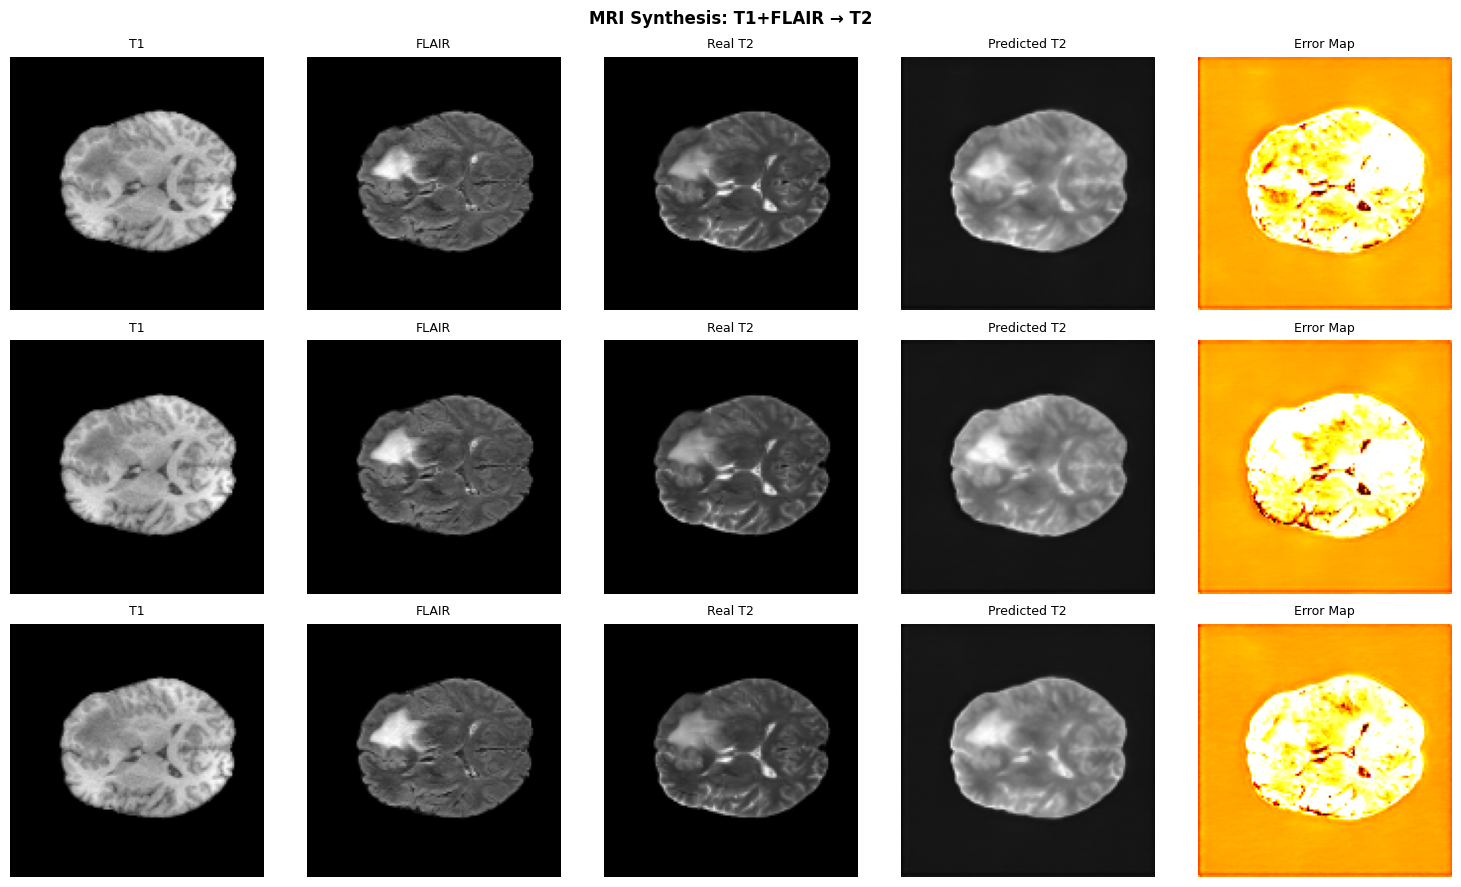

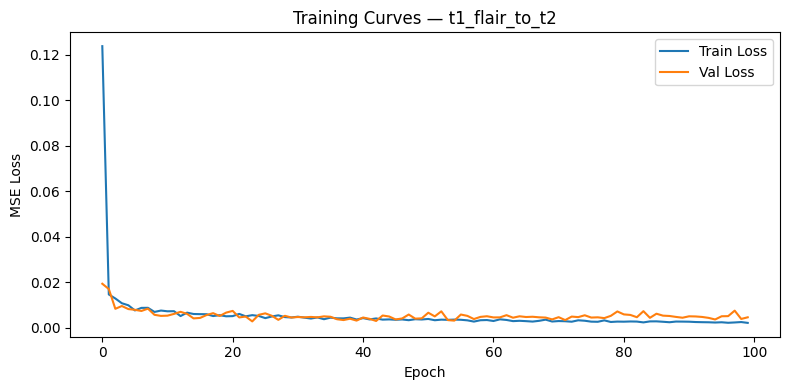


EXPERIMENT: T2+FLAIR → T1
Train/Val/Test subjects: 150/20/30
Train slices: 3,000 | Val: 400 | Test: 600
Model parameters: 32,596,610


  Epoch   1/100 | Train: 0.1207 | Val: 0.0244 | Best: 0.0244 | 76s/ep


  Epoch   5/100 | Train: 0.0103 | Val: 0.0124 | Best: 0.0085 | 77s/ep


  Epoch  10/100 | Train: 0.0089 | Val: 0.0088 | Best: 0.0078 | 77s/ep


  Epoch  15/100 | Train: 0.0054 | Val: 0.0081 | Best: 0.0066 | 77s/ep


...

  Epoch  95/100 | Train: 0.0028 | Val: 0.0066 | Best: 0.0036 | 76s/ep


  Epoch 100/100 | Train: 0.0026 | Val: 0.0054 | Best: 0.0036 | 76s/ep

✅ Training done. Best val loss: 0.0036
   Checkpoint: /kaggle/working/checkpoints/best_t2_flair_to_t1.pt


Evaluating: 100%|██████████| 20/20 [02:05<00:00,  6.26s/it]



📊 Test Results — t2_flair_to_t1
   SSIM: 0.2574
   PSNR: 17.4792
   LPIPS: 0.0799
   SSIM_std: 0.0326
   PSNR_std: 0.8789


Saved: /kaggle/working/results/qual_t2_flair_to_t1.png


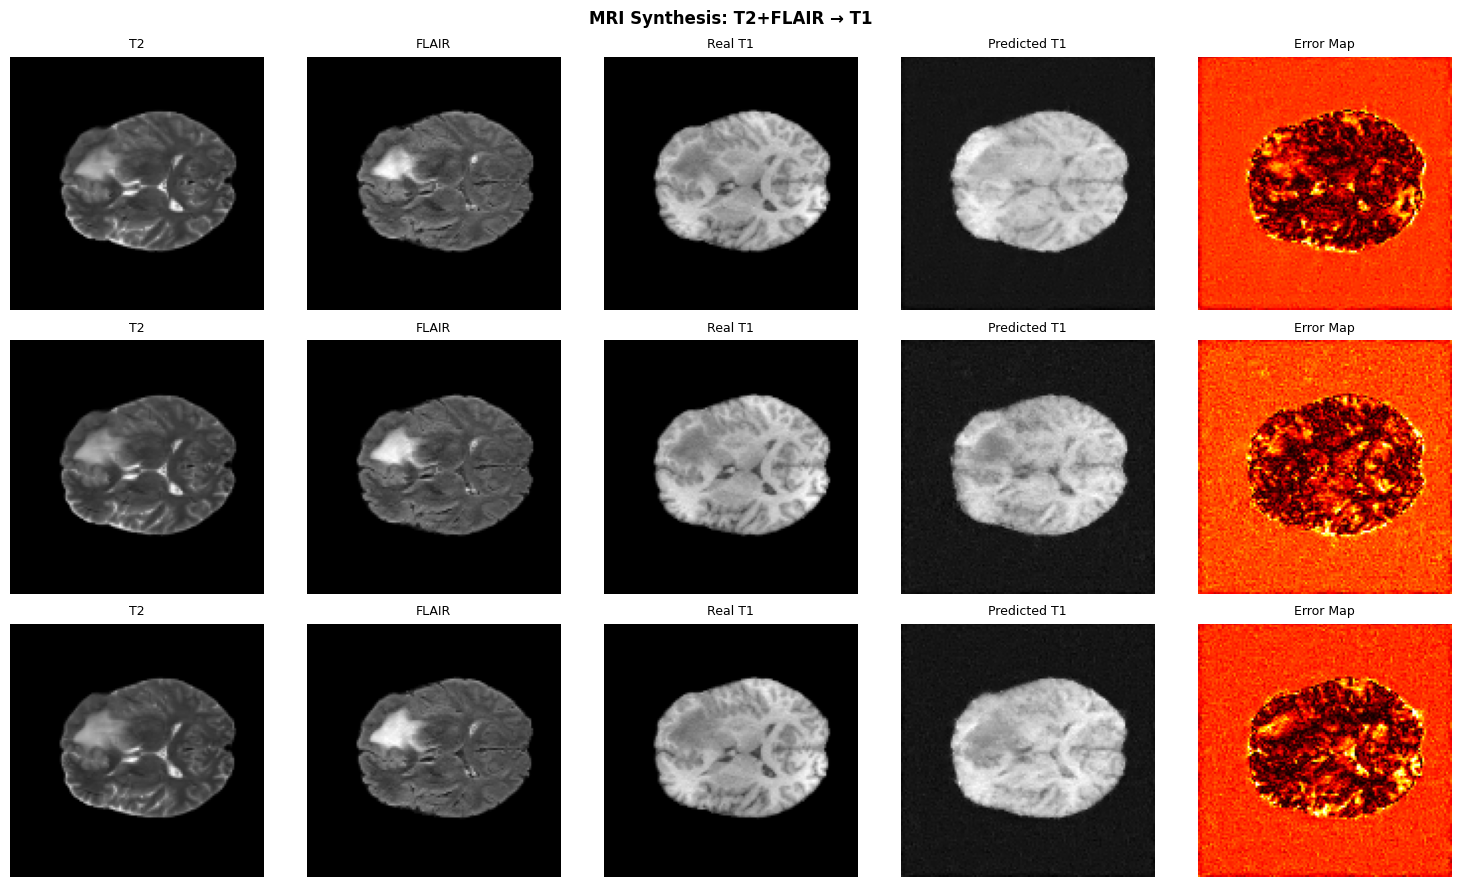

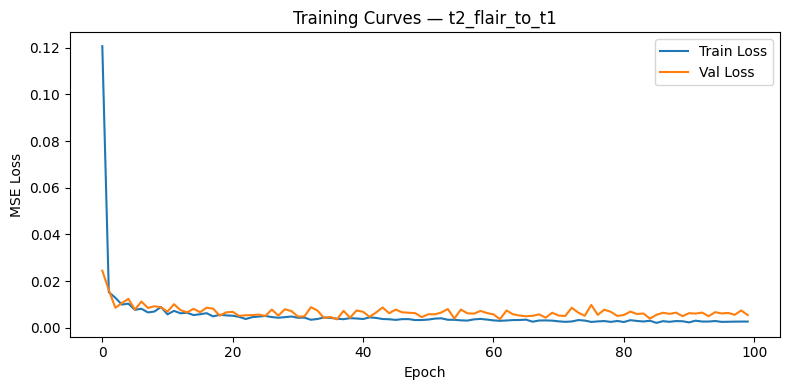


EXPERIMENT: T1+T2+FLAIR → T1CE
Train/Val/Test subjects: 150/20/30
Train slices: 3,000 | Val: 400 | Test: 600
Model parameters: 32,596,610


  Epoch   1/100 | Train: 0.1220 | Val: 0.0186 | Best: 0.0186 | 80s/ep


  Epoch   5/100 | Train: 0.0075 | Val: 0.0076 | Best: 0.0076 | 80s/ep


  Epoch  10/100 | Train: 0.0053 | Val: 0.0063 | Best: 0.0043 | 80s/ep


  Epoch  15/100 | Train: 0.0042 | Val: 0.0034 | Best: 0.0033 | 80s/ep


...

  Epoch  95/100 | Train: 0.0021 | Val: 0.0042 | Best: 0.0021 | 80s/ep


  Epoch 100/100 | Train: 0.0018 | Val: 0.0039 | Best: 0.0021 | 80s/ep

✅ Training done. Best val loss: 0.0021
   Checkpoint: /kaggle/working/checkpoints/best_t1_t2_flair_to_t1ce.pt


Evaluating: 100%|██████████| 20/20 [02:10<00:00,  6.51s/it]



📊 Test Results — t1_t2_flair_to_t1ce
   SSIM: 0.3281
   PSNR: 23.4506
   LPIPS: 0.0652
   SSIM_std: 0.0442
   PSNR_std: 2.9532


Saved: /kaggle/working/results/qual_t1_t2_flair_to_t1ce.png


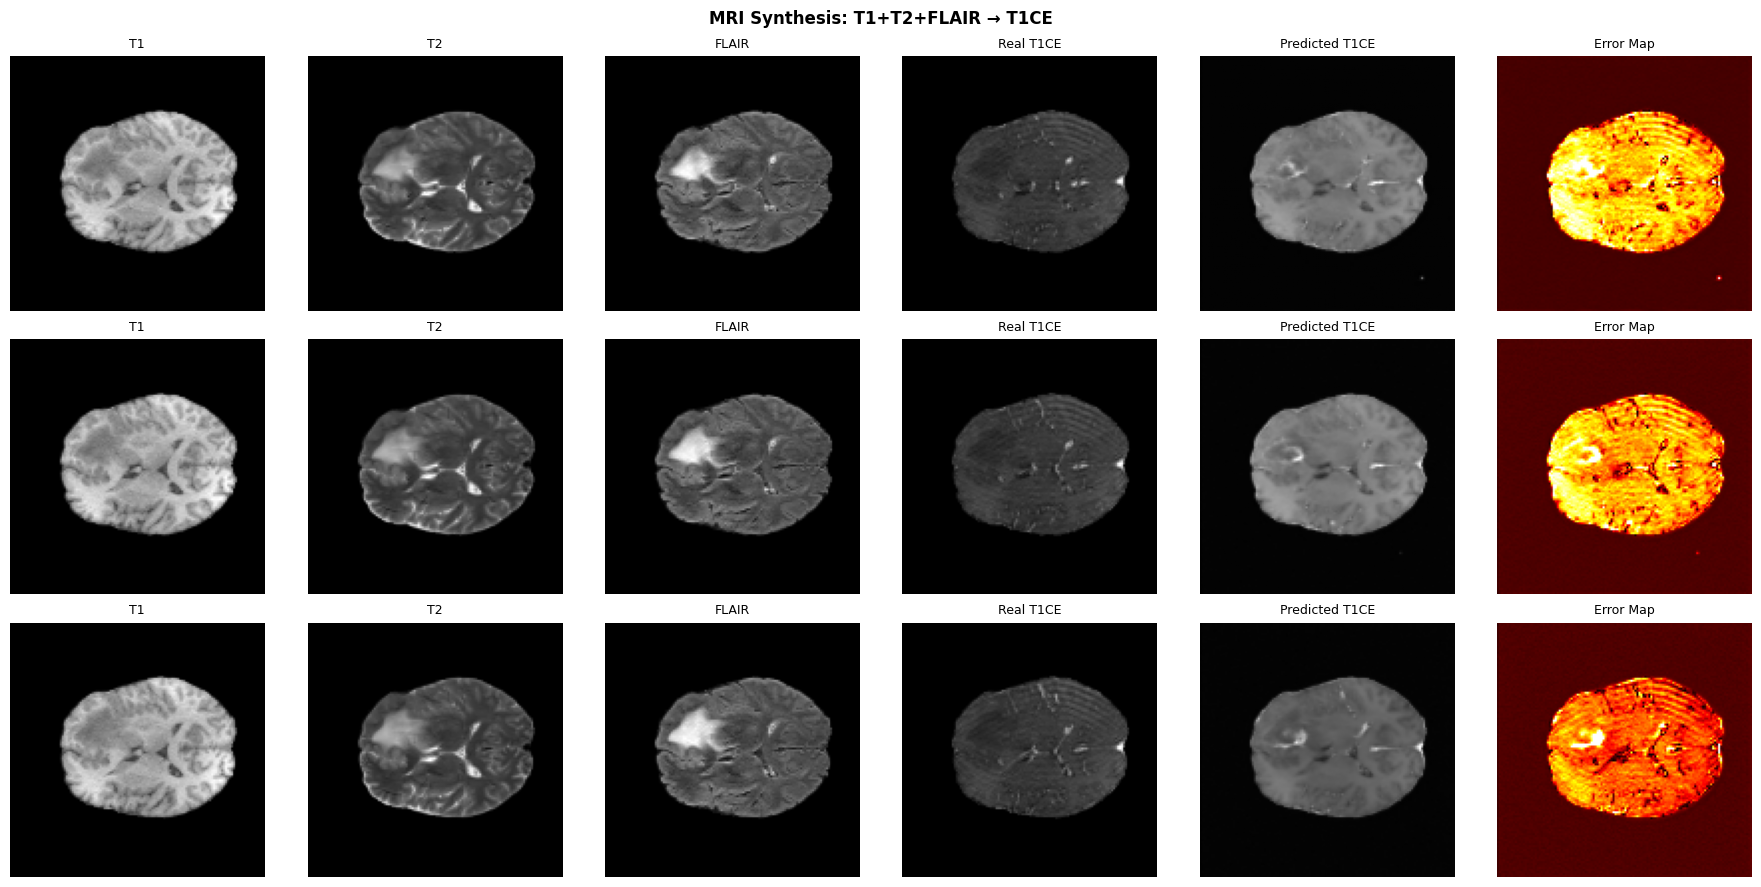

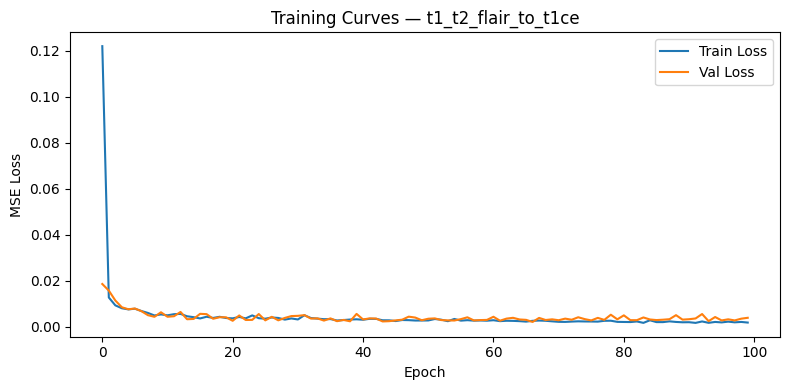

Train/Val/Test subjects: 150/20/30
Train slices: 3,000 | Val: 400 | Test: 600

🔬 Ablation: Full Model (Ours)


  Epoch   1/20 | Train: 0.1198 | Val: 0.0124 | Best: 0.0124 | 77s/ep


  Epoch   5/20 | Train: 0.0092 | Val: 0.0080 | Best: 0.0080 | 77s/ep


  Epoch  10/20 | Train: 0.0076 | Val: 0.0066 | Best: 0.0066 | 77s/ep


  Epoch  15/20 | Train: 0.0058 | Val: 0.0053 | Best: 0.0051 | 77s/ep


...

  Epoch  15/20 | Train: 0.0057 | Val: 0.0046 | Best: 0.0031 | 43s/ep


  Epoch  20/20 | Train: 0.0046 | Val: 0.0050 | Best: 0.0031 | 43s/ep

✅ Training done. Best val loss: 0.0031
   Checkpoint: /kaggle/working/checkpoints/best_ablation_w_o_Cross-Attention.pt


Evaluating: 100%|██████████| 10/10 [00:35<00:00,  3.52s/it]


   SSIM: 0.3365 | PSNR: 17.2566 | LPIPS: 0.1215

🔬 Ablation: Baseline U-Net


RuntimeError: Given groups=1, weight of size [64, 2, 4, 4], expected input[16, 1, 128, 128] to have 2 channels, but got 1 channels instead

In [19]:
all_results = {}

# ── Run primary experiment: T1+T2 → FLAIR ──────────────────────────────
model_main, metrics_main, history_main = run_experiment(
    input_seqs=["t1", "t2"],
    target_seq="flair",
    cfg=CFG,
    exp_tag="t1t2_to_flair",
    use_wandb=False   # set True if you have wandb account
)
all_results["T1+T2→FLAIR"] = metrics_main

# ── Run all 4 experiments (uncomment when GPU time allows) ─────────────
for input_seqs, target_seq in CFG["experiments"][1:]:
    _, m, _ = run_experiment(input_seqs, target_seq, CFG)
    all_results[f"{'_'.join(input_seqs)}→{target_seq}"] = m

# ── Ablation studies ────────────────────────────────────────────────────
ablation_results = run_ablations(["t1", "t2"], "flair", CFG)

# ── Final Summary Table ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print("FINAL RESULTS SUMMARY")
print(f"{'Experiment':<30} {'SSIM':>8} {'PSNR':>8} {'LPIPS':>8}")
print("-" * 68)
for exp_name, m in all_results.items():
    print(f"{exp_name:<30} {m['SSIM']:>8.4f} {m['PSNR']:>8.2f} {m['LPIPS']:>8.4f}")

print("\n✅ All experiments complete! Results saved to:", CFG["results_dir"])
print("   Ready to draft the paper 🎉")

## 🔐 Section 5 — Security & Privacy Considerations in AIoT Healthcare Deployment

The deployment of deep learning models for medical image synthesis within AIoT-connected healthcare networks introduces a set of security and privacy challenges that must be explicitly addressed. This section analyses the threat landscape and demonstrates how SeqDiff's edge-inference architecture provides structural privacy protections by design.

**ITC Track 4 mapping:** Subtopic 14 — Security and privacy issues in virtualized environments.

---

### 5.1 Threat Model

We consider the following threat vectors in the SeqDiff AIoT deployment context:

**T1 — Network Eavesdropping on MRI Transmission**
Raw MRI volumes transmitted over hospital IoT networks are sensitive PHI (Protected Health Information). An adversary with access to the network link can intercept unencrypted DICOM streams. *Mitigation*: TLS/DTLS encryption on all Tier 1 → Tier 2 links; DICOM TLS (port 2762). SeqDiff's edge-inference design reduces the window of exposure — only 2 sequences are ever transmitted over the IoT link, and raw volumes never traverse the public internet.

**T2 — Model Inversion Attacks**
A trained synthesis model encodes information about its training distribution. Adversaries with black-box or white-box access to the SeqDiff model weights could attempt model inversion attacks to reconstruct approximate training images. *Mitigation*: Differential Privacy during training (DP-SGD with calibrated noise), model weight encryption at rest, and access-controlled deployment on edge nodes.

**T3 — Membership Inference Attacks**
An attacker queries the model to determine whether a specific patient's scan was in the training dataset — a direct privacy violation under HIPAA/GDPR. *Mitigation*: DP-SGD training provides formal (ε, δ)-differential privacy guarantees, bounding membership inference advantage. Shadow model defences can further reduce risk.

**T4 — Adversarial Input Perturbations**
Deliberately perturbed input sequences (adversarial examples) could cause SeqDiff to generate diagnostically misleading synthetic sequences — a patient safety risk. *Mitigation*: Input validation at the edge node (anomaly detection on input statistics), and confidence-gated synthesis (flagging outputs with high uncertainty for radiologist review).

**T5 — Federated Learning Poisoning**
In the federated cloud training tier, a malicious hospital node could submit poisoned gradient updates to corrupt the global model. *Mitigation*: Byzantine-robust aggregation (e.g., FedAvg with Krum or coordinate-wise median), anomaly detection on gradient norms, and cryptographic attestation of participating nodes.

---

### 5.2 Edge Inference as Privacy-Preserving Architecture

A key insight is that SeqDiff's **edge-first deployment is privacy-preserving by architecture**, not merely by policy. By running inference at Tier 2 (the hospital edge node):

1. **Raw patient MRI data never leaves the hospital network.** The cloud receives only synthesized outputs — not raw acquired sequences. This satisfies the data minimisation principle of GDPR Article 5(1)(c).

2. **Federated learning with no raw data sharing.** Model updates in the cloud tier are gradient-based, not data-based. Combined with DP-SGD, this provides a mathematically rigorous privacy guarantee.

3. **Reduced attack surface on IoT links.** By transmitting only 2 of 4 sequences over the constrained IoT network, the exposure window for eavesdropping attacks is halved compared to full-study transmission.

This architectural approach aligns with the **Privacy-by-Design** framework (ISO/IEC 29101) and is directly applicable to virtualised healthcare network environments as described in ITC Track 4 Subtopic 14.

---

### 5.3 Compliance Mapping

| Regulation | Requirement | SeqDiff AIoT Compliance |
|---|---|---|
| HIPAA | PHI must be protected in transit and at rest | TLS on IoT links; raw data stays on-site |
| GDPR Art. 5 | Data minimisation | Only 2 sequences transmitted; edge synthesis |
| GDPR Art. 25 | Privacy by design | Edge-inference architecture enforces data locality |
| ISO 27001 | Information security management | Encrypted model weights; access control |
| DP Guarantee | (ε, δ)-privacy for training data | DP-SGD in federated training loop |

## 🔭 AIoT Future Work & Conclusion Notes

The SeqDiff framework, when deployed within the three-tier AIoT architecture described above, opens the following research directions that represent direct extensions for future work:

1. **On-device quantisation for ultra-low-power IoT nodes** — applying INT8/INT4 quantisation to SeqDiff for deployment on embedded edge hardware (NVIDIA Jetson, Raspberry Pi CM4) with sub-watt inference budgets.

2. **Adaptive sequence selection under bandwidth budget** — a reinforcement learning agent that decides *which* sequences to transmit given a current network budget, maximising synthesis quality subject to bandwidth constraints.

3. **Federated fine-tuning across heterogeneous IoT scanners** — extending the zero-shot capability with federated domain adaptation, allowing the cloud model to continuously improve from distributed hospital edge nodes without sharing patient data.

4. **Noisy channel robustness** — evaluating SeqDiff synthesis quality when input sequences are degraded by lossy compression or channel noise during IoT transmission, directly connecting to ITC Track 4 Subtopic 13.

These directions position SeqDiff not merely as a synthesis model, but as a foundational component of next-generation AIoT-enabled diagnostic imaging infrastructure.